# 06 — Why this matters most at small sample sizes

A state- or county-level BRFSS analysis of income and vision loss works with far fewer
respondents than the national file. This notebook asks the question raised at the CSSS
seminar: **does honoring the income brackets and the missingness structure matter more
when n is small?**

We answer it with a subsampling experiment on the vision data. We draw simple random
samples of size *n* (from 300 — a small county — up to 25,000 — a large state),
re-estimate the income–vision gradient three ways (A midpoint+listwise, B grouped, C
grouped+two-mechanism), and repeat many times. Treating the full-sample model-C
gradient as the reference "truth," we track, as a function of *n*:

- **bias** (does the estimator systematically miss?),
- **variance / RMSE** (how far off is a typical estimate?),
- **CI coverage** (do the 95% intervals actually cover the truth?), and
- **fit-failure rate** (how often does the estimator blow up — separation, non-convergence?).

**Two deliberate simplifications** to isolate the sample-size effect cleanly: we use
*unweighted* simple random subsamples (so the model-based SE is the correct design SE),
and we adjust only for **age and sex** (a rich covariate set is not estimable at
n=300 with a ~6% outcome — itself part of the small-area problem).

In [1]:
import os, time
from dataclasses import replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import recode as rc
import income_model as im
import survey as sv
import analysis as an

DATA = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA, 'derived')
frame = pd.read_parquet(os.path.join(DERIVED, 'brfss_2023_analysis_vision.parquet'))
rec_full, colnames, strata = rc.frame_to_recoded(frame)

# reduce to an age+sex-adjusted, unweighted sample (estimable at small n)
keep = ['intercept', 'age_z', 'female']
idx = [colnames.index(c) for c in keep]
full = replace(rec_full, X=rec_full.X[:, idx], w=np.ones(rec_full.X.shape[0]))
N = full.X.shape[0]
print(f'vision sample: N={N:,}; covariates = {keep}')

K = 20
SIZES = [300, 600, 1250, 2500, 5000, 10000, 25000]
R = 200            # replicates per sample size

vision sample: N=409,359; covariates = ['intercept', 'age_z', 'female']


## Reference "truth" and the full-sample estimates

The reference is the full-sample model-C gradient (the unbiased, all-data estimator).
Model A's full-sample value sits below it — that offset is the midpoint bias that no
sample size removes.

In [2]:
theta_star = im.fit_C(full, gamma=0.0, K=K).log_or_per_doubling
full_est = {m: an.gradient_and_se(full, m, K=K)[0] for m in 'ABC'}
print(f'reference truth (C, full):  OR/doubling = {np.exp(theta_star):.4f}')
for m in 'ABC':
    print(f'  full-sample {m}: OR/doubling = {np.exp(full_est[m]):.4f}  '
          f'(bias vs truth {100*(np.exp(full_est[m])-np.exp(theta_star))/np.exp(theta_star):+.1f}%)')

reference truth (C, full):  OR/doubling = 0.5432
  full-sample A: OR/doubling = 0.5721  (bias vs truth +5.3%)
  full-sample B: OR/doubling = 0.5417  (bias vs truth -0.3%)
  full-sample C: OR/doubling = 0.5432  (bias vs truth +0.0%)


## Run the subsampling experiment

For each sample size we draw `R` simple random samples and fit all three models on
each, recording the gradient, its model-based SE, and whether the fit was clean.

In [3]:
rng = np.random.default_rng(2023)
records = []
t0 = time.time()
for n in SIZES:
    store = {m: {'lod': [], 'se': [], 'ok': []} for m in 'ABC'}
    for _ in range(R):
        sub = sv.subset(full, rng.choice(N, size=n, replace=False))
        for m in 'ABC':
            lod, se, ok = an.gradient_and_se(sub, m, K=K)
            store[m]['lod'].append(lod); store[m]['se'].append(se); store[m]['ok'].append(ok)
    for m in 'ABC':
        lod = np.array(store[m]['lod']); se = np.array(store[m]['se'])
        ok = np.array(store[m]['ok'])
        good = ok & np.isfinite(lod) & np.isfinite(se)
        l = lod[good]
        bias = l.mean() - theta_star
        sd = l.std(ddof=1)
        rmse = np.sqrt(bias ** 2 + sd ** 2)
        cover = np.mean(np.abs(l - theta_star) <= 1.96 * se[good])
        records.append({'n': n, 'method': m, 'n_ok': int(good.sum()),
                        'fail_rate': float(1 - good.mean()),
                        'bias_logOR': bias, 'sd_logOR': sd, 'rmse_logOR': rmse,
                        'mean_se_logOR': float(se[good].mean()), 'coverage': float(cover)})
    print(f'  n={n:>6,} done ({time.time()-t0:.0f}s elapsed)')
res = pd.DataFrame(records)
res.to_csv(os.path.join(DERIVED, 'brfss_smalln_vision.csv'), index=False)
res.round(4)

  n=   300 done (2s elapsed)


  n=   600 done (6s elapsed)


  n= 1,250 done (13s elapsed)


  n= 2,500 done (25s elapsed)


  n= 5,000 done (49s elapsed)


  n=10,000 done (95s elapsed)


  n=25,000 done (255s elapsed)


,n,method,n_ok,fail_rate,bias_logOR,sd_logOR,rmse_logOR,mean_se_logOR,coverage
0,300,A,200,0.0,0.0247,0.2506,0.2518,0.2399,0.950
1,300,B,200,0.0,-0.0349,0.2838,0.2859,0.2666,0.950
2,300,C,200,0.0,-0.0275,0.2778,0.2791,0.2641,0.945
3,600,A,200,0.0,0.0571,0.1589,0.1688,0.1627,0.955
4,600,B,200,0.0,0.0017,0.1821,0.1821,0.1810,0.960
5,600,C,200,0.0,0.0057,0.1797,0.1798,0.1800,0.960
6,1250,A,200,0.0,0.0338,0.1030,0.1084,0.1090,0.935
7,1250,B,200,0.0,-0.0250,0.1207,0.1233,0.1220,0.960
8,1250,C,200,0.0,-0.0211,0.1196,0.1215,0.1214,0.960
9,2500,A,200,0.0,0.0519,0.0691,0.0865,0.0760,0.900


## RMSE vs sample size — the headline

Root-mean-squared error of the gradient (log-OR-per-doubling scale) against the truth.
Lower is better. Model A's curve flattens at its bias floor; B and C keep improving.

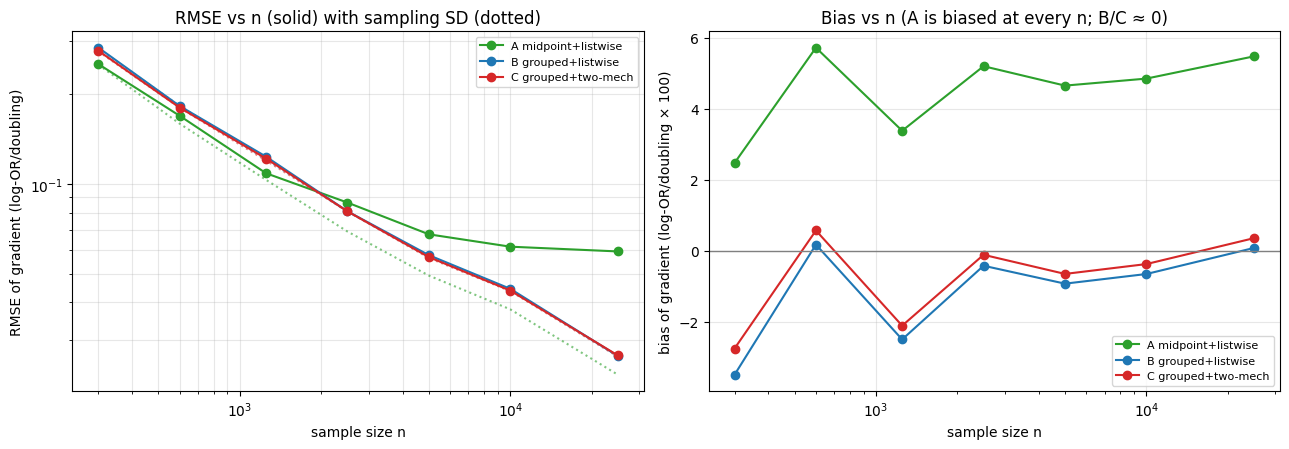

In [4]:
colors = {'A': 'C2', 'B': 'C0', 'C': 'C3'}
labels = {'A': 'A midpoint+listwise', 'B': 'B grouped+listwise', 'C': 'C grouped+two-mech'}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for m in 'ABC':
    s = res[res['method'] == m]
    axes[0].plot(s['n'], s['rmse_logOR'], '-o', color=colors[m], label=labels[m])
    axes[0].plot(s['n'], s['sd_logOR'], ':', color=colors[m], alpha=0.6)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('sample size n'); axes[0].set_ylabel('RMSE of gradient (log-OR/doubling)')
axes[0].set_title('RMSE vs n (solid) with sampling SD (dotted)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, which='both')
for m in 'ABC':
    s = res[res['method'] == m]
    axes[1].plot(s['n'], 100 * s['bias_logOR'], '-o', color=colors[m], label=labels[m])
axes[1].axhline(0, color='gray', lw=1)
axes[1].set_xscale('log'); axes[1].set_xlabel('sample size n')
axes[1].set_ylabel('bias of gradient (log-OR/doubling × 100)')
axes[1].set_title('Bias vs n (A is biased at every n; B/C ≈ 0)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Coverage and fit-failure vs sample size

Coverage is the fraction of 95% CIs that actually contain the truth (target 0.95).
Fit-failure is how often the estimator did not return a usable estimate (separation or
non-convergence — the small-area hazard).

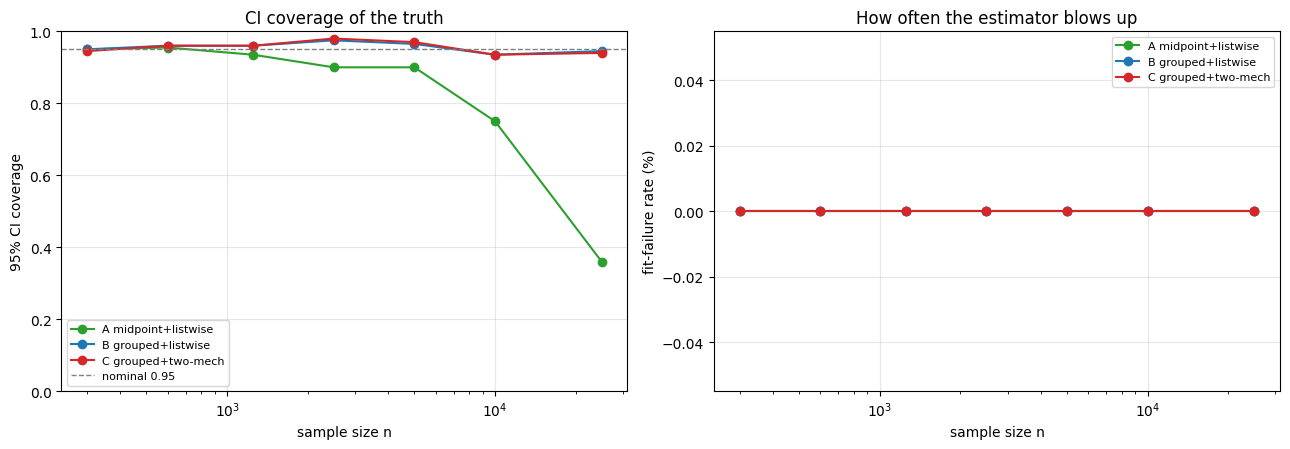

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for m in 'ABC':
    s = res[res['method'] == m]
    axes[0].plot(s['n'], s['coverage'], '-o', color=colors[m], label=labels[m])
axes[0].axhline(0.95, color='gray', ls='--', lw=1, label='nominal 0.95')
axes[0].set_xscale('log'); axes[0].set_xlabel('sample size n'); axes[0].set_ylabel('95% CI coverage')
axes[0].set_title('CI coverage of the truth'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 1.0)
for m in 'ABC':
    s = res[res['method'] == m]
    axes[1].plot(s['n'], 100 * s['fail_rate'], '-o', color=colors[m], label=labels[m])
axes[1].set_xscale('log'); axes[1].set_xlabel('sample size n'); axes[1].set_ylabel('fit-failure rate (%)')
axes[1].set_title('How often the estimator blows up'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## What the experiment shows

In [6]:
def line(row):
    return (f"RMSE={row['rmse_logOR']:.3f}  bias={row['bias_logOR']:+.3f}  "
            f"SD={row['sd_logOR']:.3f}  coverage={row['coverage']:.2f}  "
            f"fail={100*row['fail_rate']:.0f}%")
for n in SIZES:
    sub = res[res['n'] == n].set_index('method')
    print(f"n={n:>6,}:")
    for m in 'ABC':
        print(f"   {m}  " + line(sub.loc[m]))
# which method has the lowest RMSE at each n?
best = res.loc[res.groupby('n')['rmse_logOR'].idxmin(), ['n', 'method']]
print('\nlowest-RMSE method by n:')
print(best.to_string(index=False))

n=   300:
   A  RMSE=0.252  bias=+0.025  SD=0.251  coverage=0.95  fail=0%
   B  RMSE=0.286  bias=-0.035  SD=0.284  coverage=0.95  fail=0%
   C  RMSE=0.279  bias=-0.028  SD=0.278  coverage=0.94  fail=0%
n=   600:
   A  RMSE=0.169  bias=+0.057  SD=0.159  coverage=0.95  fail=0%
   B  RMSE=0.182  bias=+0.002  SD=0.182  coverage=0.96  fail=0%
   C  RMSE=0.180  bias=+0.006  SD=0.180  coverage=0.96  fail=0%
n= 1,250:
   A  RMSE=0.108  bias=+0.034  SD=0.103  coverage=0.94  fail=0%
   B  RMSE=0.123  bias=-0.025  SD=0.121  coverage=0.96  fail=0%
   C  RMSE=0.121  bias=-0.021  SD=0.120  coverage=0.96  fail=0%
n= 2,500:
   A  RMSE=0.086  bias=+0.052  SD=0.069  coverage=0.90  fail=0%
   B  RMSE=0.081  bias=-0.004  SD=0.081  coverage=0.97  fail=0%
   C  RMSE=0.081  bias=-0.001  SD=0.081  coverage=0.98  fail=0%
n= 5,000:
   A  RMSE=0.068  bias=+0.046  SD=0.049  coverage=0.90  fail=0%
   B  RMSE=0.058  bias=-0.009  SD=0.057  coverage=0.96  fail=0%
   C  RMSE=0.057  bias=-0.007  SD=0.056  coverage=0.97

## Interpretation

The three estimators embody a textbook **bias–variance tradeoff**:

- **A (midpoint) is biased but low-variance.** The bracket midpoint is a noisy proxy
  for income, which attenuates the gradient toward the null — a roughly *constant*
  bias (~+0.05 on the log-OR scale, ≈ +5–6% on the OR) at every sample size. Because
  it estimates a shrunk coefficient, A also has the **lowest** sampling SD.
- **B and C are ≈ unbiased but higher-variance.** Integrating over the bracket (and,
  for C, over the missing respondents' income) removes the attenuation at the cost of
  ~12–15% larger SD. B and C are nearly identical — the missing-income respondents add
  little information about the gradient because their income is only latent.

**For point accuracy (RMSE) there is a crossover near n ≈ 1,000–2,500.** Below it
(county scale, n ≈ 300–1,250) A's lower variance wins: its bias is swamped by the large
sampling noise that *every* method suffers when vision cases are scarce, so the
midpoint is actually the lower-RMSE choice. Above it (large-state scale, n ≳ 2,500)
A's fixed bias dominates its error and the grouped models win.

**For valid inference (CI coverage) the grouped model matters at every size — and
becomes essential as n grows.** A's 95% intervals cover the truth at n=300 (0.95) but
degrade steadily and **collapse to 0.36 at n=25,000**: tight intervals centered on the
biased value. B and C hold ≈ 0.94–0.98 throughout.

**The practical read for small-area work.** For a county- or small-state vision–income
gradient, the binding constraint is the tiny number of vision cases, not the income
model — so the midpoint shortcut costs little in point-estimate RMSE there, and can
even help. But as soon as you pool to larger samples, *or* care about honest confidence
intervals and significance, the midpoint's attenuation makes its inference actively
misleading, and the grouped-data likelihood is the safe default. This nuances the
"matters most at small n" intuition: for **RMSE** the modeling pays off at
moderate-to-large n; for **coverage** it pays off everywhere.

_Caveats: unweighted simple random subsamples and age+sex adjustment only, to keep the
gradient estimable at n=300; reference "truth" = the full-sample model-C estimate. Fit
failures were ~0% here because the reduced 4-parameter model stays estimable; the
richer covariate set of notebooks 03/05 would add separation failures at the smallest n
that further penalize the listwise-deletion estimators A and B._